In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/sample_submission.csv
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/train.csv
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test.csv
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/b3f67ac077531f44dd06275af31edbd9.png
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/e94fde220360e4b769921e16059cc6af.png
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/d2993271d0a49d1d821db1174861629a.png
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/99732e844196448b90e50973d6ba5224.png
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/3c6f70f56258cad13d74e7f17da1c7c5.png
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/5d6a25163584e7b05a528d3f94fda500.png
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/435c653f95dd47326063ff145a0fa82e.png
/kaggle/input/vinbigdata-512-image-dataset/vinbigdata/test/3020abca19e8fa4bba62fe583f07050d.png
/kaggle/input/vinbigdata-512-

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, f1_score, classification_report

import torchvision
from torchvision import transforms, models
import timm

In [3]:
import cv2


class CLAHE:
    """Apply Contrast-Limited AHE to each RGB image."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit,
                                     tileGridSize=tile_grid_size)
    def __call__(self, img):
        arr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
        eq  = self.clahe.apply(arr)
        eq3 = cv2.cvtColor(eq, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(eq3)


In [4]:
# 1. Paths & params
DATA_DIR    = "/kaggle/input/vinbigdata-512-image-dataset/vinbigdata"
IMG_DIR     = os.path.join(DATA_DIR, "train")  # folder of PNG images
CSV_PATH    = os.path.join(DATA_DIR, "train.csv")
BATCH_SIZE  = 16
NUM_EPOCHS  = 10
LR          = 1e-4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# 1. Load original CSV
df = pd.read_csv(CSV_PATH)

# 2. Define original-to-new class grouping
new_class_mapping = {
    'No finding': 'no_finding',                    # Class 0
    'Aortic enlargement': 'vascular_abnormality',    # Class 1
    # All others grouped under 'other_conditions' -> Class 2
    'Atelectasis': 'nonvascular_abnormality',
    'Calcification': 'nonvascular_abnormality',
    'Cardiomegaly': 'nonvascular_abnormality',
    'Consolidation': 'nonvascular_abnormality',
    'ILD': 'nonvascular_abnormality',
    'Infiltration': 'nonvascular_abnormality',
    'Lung Opacity': 'nonvascular_abnormality',
    'Nodule/Mass': 'nonvascular_abnormality',
    'Other lesion': 'nonvascular_abnormality',
    'Pleural effusion': 'nonvascular_abnormality',
    'Pleural thickening': 'nonvascular_abnormality',
    'Pulmonary fibrosis': 'nonvascular_abnormality',
    'Pneumothorax': 'nonvascular_abnormality'
}


# 3. Apply mapping to the DataFrame
df["new_class"] = df["class_name"].map(new_class_mapping)

# 4. Define new classes
CLASSES = ['no_finding', 'vascular_abnormality', 'nonvascular_abnormality']
cls2idx = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

print("New CLASSES:", CLASSES)
print("Class-to-index mapping:", cls2idx)


New CLASSES: ['no_finding', 'vascular_abnormality', 'nonvascular_abnormality']
Class-to-index mapping: {'no_finding': 0, 'vascular_abnormality': 1, 'nonvascular_abnormality': 2}


In [6]:



# Step 2: Apply the mapping
df["new_class"] = df["class_name"].map(new_class_mapping)

# Step 3: Identify unmapped class names
unmapped = df[df["new_class"].isna()]["class_name"].unique()
print("Unmapped class names:", unmapped)


Unmapped class names: []


In [7]:
best_n = 7162

df_balanced = pd.concat([
    df[df["new_class"] == "no_finding"].sample(n=best_n, random_state=42),
    df[df["new_class"] == "nonvascular_abnormality"].sample(n=best_n, random_state=42),
    df[df["new_class"] == "vascular_abnormality"].sample(n=best_n, random_state=42)
]).reset_index(drop=True)


In [8]:
# Example: inverse of class frequencies
class_counts = df_balanced["new_class"].value_counts()
class_weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))


In [9]:
df_balanced = df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)


In [10]:
import torch

# Define class mapping
class_map = {
    "no_finding": 0,
    "vascular_abnormality": 1,
    "nonvascular_abnormality": 2
}

# Convert to dictionary: {image_id: tensor([class_index])}
labels_dict = {
    row["image_id"]: torch.tensor(class_map[row["new_class"]], dtype=torch.long)
    for _, row in df_balanced.iterrows()
}


In [11]:
from torch.utils.data import Dataset
from PIL import Image
import os

class VinBigDataPNGDataset(Dataset):
    def __init__(self, img_dir, labels_dict, transform=None):
        self.img_dir   = img_dir
        self.labels    = labels_dict
        self.ids       = list(labels_dict.keys())
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id   = self.ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        img      = Image.open(img_path).convert("RGB")
        
        if self.transform:
            img = self.transform(img)

        label = self.labels[img_id]  # tensor: either class index or one-hot
        return img, label


In [12]:
# 4. Transforms — enhanced augmentation pipeline
tfms = transforms.Compose([
    # random crop + resize for scale & translation robustness
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.75, 1.33)),
    
    # flips & small rotations
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    
    # slight color/exposure jitter
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    
    # local contrast enhancement
    CLAHE(),
    
    # tensor conversion and ImageNet normalization
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    
    # cut-out regularization
    transforms.RandomErasing(p=0.2),
    
    # optional: simulate blur
    # transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
])


Resnet

In [13]:
def train_model(model, optimizer, criterion, train_loader: DataLoader,
                num_epochs: int, device, model_name="Model"):
    model.to(device)
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"{model_name} — Epoch {epoch}/{num_epochs} — loss: {epoch_loss:.4f}")
    return model

In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import numpy as np

def evaluate_model(model, data_loader, device, classes, threshold=0.5, name="Model"):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, targets in data_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs   = torch.sigmoid(outputs).cpu().numpy()
            preds   = (probs > threshold).astype(int)
            y_pred.append(preds)
            y_true.append(targets.numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    report   = classification_report(y_true, y_pred, target_names=classes)

    print(f"\n🗂️  {name} Evaluation:")
    print(f"✅ Accuracy: {acc:.4f}")
    print(f"✅ Macro F1 Score: {macro_f1:.4f}")
    print("📊 Classification Report:")
    print(report)

    return {"accuracy": acc, "macro_f1": macro_f1, "report": report}


In [15]:
criterion = nn.BCEWithLogitsLoss()

In [16]:
# ResNet-50
resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet = resnet.to(DEVICE)
opt_resnet = optim.Adam(resnet.parameters(), lr=LR)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s] 


In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_balanced["encoded"] = label_encoder.fit_transform(df_balanced["new_class"])
class_names = label_encoder.classes_.tolist()  # ['no_finding', 'nonvascular_abnormality', 'vascular_abnormality']


In [18]:
import numpy as np

labels_dict = {
    row["image_id"]: np.eye(len(class_names))[row["encoded"]]
    for _, row in df_balanced.iterrows()
}


In [19]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = VinBigDataPNGDataset(img_dir=IMG_DIR, labels_dict=labels_dict, transform=transform)


In [20]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)


In [21]:
# Usage for ResNet-50


resnet = train_model(
    model=resnet,
    optimizer=opt_resnet,
    criterion=criterion,
    train_loader = train_loader,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    model_name="ResNet-50"
)

ResNet-50 — Epoch 1/10 — loss: 0.3167
ResNet-50 — Epoch 2/10 — loss: 0.2249
ResNet-50 — Epoch 3/10 — loss: 0.1664
ResNet-50 — Epoch 4/10 — loss: 0.1066
ResNet-50 — Epoch 5/10 — loss: 0.0691
ResNet-50 — Epoch 6/10 — loss: 0.0442
ResNet-50 — Epoch 7/10 — loss: 0.0332
ResNet-50 — Epoch 8/10 — loss: 0.0481
ResNet-50 — Epoch 9/10 — loss: 0.0211
ResNet-50 — Epoch 10/10 — loss: 0.0241


In [22]:
resnet90_metrics = evaluate_model(resnet, val_loader, DEVICE, CLASSES, name="Resnet-50")


🗂️  Resnet-50 Evaluation:
✅ Accuracy: 0.7977
✅ Macro F1 Score: 0.7103
📊 Classification Report:
                         precision    recall  f1-score   support

             no_finding       0.92      0.96      0.94      1122
   vascular_abnormality       0.82      0.33      0.47       410
nonvascular_abnormality       0.61      0.89      0.72       430

              micro avg       0.81      0.81      0.81      1962
              macro avg       0.78      0.72      0.71      1962
           weighted avg       0.83      0.81      0.79      1962
            samples avg       0.80      0.81      0.81      1962



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [23]:
# VGG-19
vgg19 = models.vgg19(pretrained=True)
vgg19.classifier[6] = nn.Linear(vgg19.classifier[6].in_features, NUM_CLASSES)
vgg19 = vgg19.to(DEVICE)
opt_vgg19 = optim.Adam(vgg19.parameters(), lr=LR)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 226MB/s]  


In [24]:
# Usage for VGG-19
vgg19 = train_model(
    model=vgg19,
    optimizer=opt_vgg19,
    criterion=criterion,
    train_loader=train_loader,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    model_name="VGG-19"
)

VGG-19 — Epoch 1/10 — loss: 0.3794
VGG-19 — Epoch 2/10 — loss: 0.2882
VGG-19 — Epoch 3/10 — loss: 0.2605
VGG-19 — Epoch 4/10 — loss: 0.2403
VGG-19 — Epoch 5/10 — loss: 0.2205
VGG-19 — Epoch 6/10 — loss: 0.1856
VGG-19 — Epoch 7/10 — loss: 0.1629
VGG-19 — Epoch 8/10 — loss: 0.1377
VGG-19 — Epoch 9/10 — loss: 0.0995
VGG-19 — Epoch 10/10 — loss: 0.0802


In [25]:
vgg19_metrics    = evaluate_model(vgg19, val_loader, DEVICE, CLASSES, name="VGG-19")


🗂️  VGG-19 Evaluation:
✅ Accuracy: 0.7997
✅ Macro F1 Score: 0.7206
📊 Classification Report:
                         precision    recall  f1-score   support

             no_finding       0.91      0.97      0.94      1122
   vascular_abnormality       0.58      0.60      0.59       410
nonvascular_abnormality       0.71      0.57      0.63       430

              micro avg       0.81      0.81      0.81      1962
              macro avg       0.73      0.71      0.72      1962
           weighted avg       0.80      0.81      0.80      1962
            samples avg       0.80      0.81      0.80      1962



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [26]:
# Xception via timm
xception = timm.create_model('xception', pretrained=True, num_classes=NUM_CLASSES)
xception = xception.to(DEVICE)
opt_xception = optim.Adam(xception.parameters(), lr=LR)

/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


In [27]:
# Usage for Xception
xception = train_model(
    model=xception,
    optimizer=opt_xception,
    criterion=criterion,
    train_loader=train_loader,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    model_name="Xception"
)

Xception — Epoch 1/10 — loss: 0.3450
Xception — Epoch 2/10 — loss: 0.2095
Xception — Epoch 3/10 — loss: 0.1253
Xception — Epoch 4/10 — loss: 0.0558
Xception — Epoch 5/10 — loss: 0.0516
Xception — Epoch 6/10 — loss: 0.0281
Xception — Epoch 7/10 — loss: 0.0234
Xception — Epoch 8/10 — loss: 0.0272
Xception — Epoch 9/10 — loss: 0.0182
Xception — Epoch 10/10 — loss: 0.0156


In [28]:
xception_metrics = evaluate_model(xception, val_loader, DEVICE, CLASSES, name="Xception")


🗂️  Xception Evaluation:
✅ Accuracy: 0.8175
✅ Macro F1 Score: 0.7479
📊 Classification Report:
                         precision    recall  f1-score   support

             no_finding       0.93      0.97      0.95      1122
   vascular_abnormality       0.66      0.59      0.62       410
nonvascular_abnormality       0.68      0.67      0.67       430

              micro avg       0.82      0.82      0.82      1962
              macro avg       0.76      0.74      0.75      1962
           weighted avg       0.82      0.82      0.82      1962
            samples avg       0.82      0.82      0.82      1962



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [29]:
# from sklearn.metrics import accuracy_score, f1_score, classification_report
# import torch
# # import numpy as np

# def evaluate_ensemble(models, data_loader, device, classes,
#                       threshold=0.5, name="Ensemble"):
#     for m in models:
#         m.to(device).eval()

#     y_true, y_pred = [], []
#     with torch.no_grad():
#         for imgs, targets in data_loader:
#             imgs = imgs.to(device)
#             # collect per-model probabilities
#             probs = []
#             for m in models:
#                 out = m(imgs)
#                 probs.append(torch.sigmoid(out).cpu().numpy())
#             # average probabilities
#             avg_probs = np.mean(probs, axis=0)
#             preds     = (avg_probs > threshold).astype(int)

#             y_true.append(targets.numpy())
#             y_pred.append(preds)

#     y_true = np.vstack(y_true)
#     y_pred = np.vstack(y_pred)

#     acc      = accuracy_score(y_true, y_pred)
#     macro_f1 = f1_score(y_true, y_pred, average='macro')
#     report   = classification_report(y_true, y_pred, target_names=classes)

#     print(f"\n🔗 {name} Averaging Evaluation:")
#     print(f"✅ Accuracy: {acc:.4f}")
#     print(f"✅ Macro F1 Score: {macro_f1:.4f}")
#     print("📊 Classification Report:")
#     print(report)

#     return {"accuracy": acc, "macro_f1": macro_f1, "report": report}

# # --- Usage ---
# # assuming resnet, vgg19, xception are already loaded/trained,
# # and val_loader, DEVICE, CLASSES are defined:

# ensemble_metrics = evaluate_ensemble(
#     models=[resnet, vgg19, xception],
#     data_loader=val_loader,
#     device=DEVICE,
#     classes=CLASSES,
#     threshold=0.5,
#     name="ResNet+VGG19+Xception"
# )

In [30]:
# vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES)

In [31]:
# vit_model = vit_model.to(DEVICE)

In [32]:
# opt_vit = optim.Adam(vit_model.parameters(), lr=LR)

In [33]:
# print(f"--- Starting training for Vision Transformer (ViT) ---")
# vit_model = train_model(
#     model=vit_model,
#     optimizer=opt_vit,
#     criterion=criterion,
#     train_loader=train_loader,
#     num_epochs=NUM_EPOCHS,
#     device=DEVICE,
#     model_name="Vision Transformer (ViT)"
# )
# print(f"--- Vision Transformer (ViT) training complete ---")

In [34]:
# print(f"\n--- Evaluating Vision Transformer (ViT) ---")
# vit_metrics = evaluate_model(
#     model=vit_model,
#     data_loader=val_loader,
#     device=DEVICE,
#     classes=CLASSES,
#     name="Vision Transformer (ViT)"
# )
# print(f"--- Vision Transformer (ViT) evaluation complete ---")

In [35]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --------- CutMix helper functions ---------
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def cutmix(data, targets, alpha=1.0):
    indices = torch.randperm(data.size(0))
    shuffled_data = data[indices]
    shuffled_targets = targets[indices]

    lam = np.random.beta(alpha, alpha)
    bbx1, bby1, bbx2, bby2 = rand_bbox(data.size(), lam)
    data[:, :, bbx1:bbx2, bby1:bby2] = shuffled_data[:, :, bbx1:bbx2, bby1:bby2]

    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (data.size(-1) * data.size(-2)))
    return data, targets, shuffled_targets, lam

# --------- Transforms for training and validation ---------
train_tfms_incep = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_tfms_incep = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --------- Dataset and DataLoader ---------
# Assuming IMG_DIR, labels_dict, val_loader, BATCH_SIZE, DEVICE are already defined
val_indices = val_loader.dataset.indices if hasattr(val_loader.dataset, "indices") else None

train_dataset_incep = VinBigDataPNGDataset(IMG_DIR, labels_dict, transform=train_tfms_incep)
val_dataset_incep = VinBigDataPNGDataset(IMG_DIR, labels_dict, transform=val_tfms_incep)
if val_indices is not None:
    val_dataset_incep = Subset(val_dataset_incep, val_indices)

train_loader_incep = DataLoader(train_dataset_incep, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader_incep = DataLoader(val_dataset_incep, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# --------- Model, Loss, Optimizer, Scheduler ---------
model_incep = inception_v3(weights=Inception_V3_Weights.DEFAULT, aux_logits=True)
model_incep.fc = nn.Linear(model_incep.fc.in_features, NUM_CLASSES)
model_incep.AuxLogits.fc = nn.Linear(model_incep.AuxLogits.fc.in_features, NUM_CLASSES)
model_incep = model_incep.to(DEVICE)

criterion_incep = nn.CrossEntropyLoss()
optimizer_incep = optim.Adam(model_incep.parameters(), lr=LR)
scheduler_incep = ReduceLROnPlateau(optimizer_incep, mode='max', factor=0.5, patience=2, verbose=True)

# --------- Training function ---------
def train_one_epoch_incep(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        if np.random.rand() < 0.5:
            imgs, targets1, targets2, lam = cutmix(imgs, labels)
            targets1, targets2 = targets1.to(device), targets2.to(device)
            output, aux_output = model(imgs)
            loss = criterion(output, targets1) * lam + criterion(output, targets2) * (1. - lam)
            loss += 0.4 * (criterion(aux_output, targets1) * lam + criterion(aux_output, targets2) * (1. - lam))
        else:
            output, aux_output = model(imgs)
            loss = criterion(output, labels) + 0.4 * criterion(aux_output, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

# --------- Evaluation function ---------
def evaluate_model_incep(model, loader, device, classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            if labels.dim() > 1 and labels.size(1) > 1:
                labels = torch.argmax(labels, dim=1)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds, target_names=classes)
    print(f"Validation Accuracy: {acc:.4f} | Validation F1: {f1:.4f}")
    print(report)
    return acc, f1

# --------- Training loop ---------
train_losses_incep, val_f1s_incep = [], []
best_f1_incep = 0

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch_incep(model_incep, train_loader_incep, criterion_incep, optimizer_incep, DEVICE)
    val_acc, val_f1 = evaluate_model_incep(model_incep, val_loader_incep, DEVICE, CLASSES)

    train_losses_incep.append(train_loss)
    val_f1s_incep.append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Validation Accuracy: {val_acc:.4f} | F1 Score: {val_f1:.4f}")

    scheduler_incep.step(val_f1)

    if val_f1 > best_f1_incep:
        best_f1_incep = val_f1
        torch.save(model_incep.state_dict(), "best_inception_model_cutmix.pth")
        print("✅ Best Inception model saved.")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:02<00:00, 45.7MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Validation Accuracy: 0.8272 | Validation F1: 0.8158
                         precision    recall  f1-score   support

             no_finding       0.92      0.97      0.95      1122
   vascular_abnormality       0.79      0.43      0.56       410
nonvascular_abnormality       0.64      0.83      0.73       430

               accuracy                           0.83      1962
              macro avg       0.78      0.74      0.74      1962
           weighted avg       0.83      0.83      0.82      1962

Epoch 1/10 - Train Loss: 0.9825
Epoch 1/10 - Validation Accuracy: 0.8272 | F1 Score: 0.8158
✅ Best Inception model saved.
Validation Accuracy: 0.8430 | Validation F1: 0.8400
                         precision    recall  f1-score   support

             no_finding       0.96      0.95      0.95      1122
   vascular_abnormality       0.80      0.52      0.63       410
nonvascular_abnormality       0.64      0.88      0.74       430

               accuracy                           0.84

In [36]:
#Stratified CV works better because:

#It ensures class balance in every fold

#It provides multiple train/val splits averaging out noise

#The meta-model trains on true out-of-fold predictions

##It prevents the meta-model from overfitting to quirks in one specific train/val split

In [37]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

def get_stacked_outputs(models_224, inception_model, loader_224, loader_299, device):
    outputs_224 = [[] for _ in models_224]
    outputs_299 = []
    targets_list = []

    for imgs, targets in loader_224:
        imgs = imgs.to(device)
        with torch.no_grad():
            for i, model in enumerate(models_224):
                preds = model(imgs)
                preds = torch.softmax(preds, dim=1).cpu().numpy()
                outputs_224[i].append(preds)
        targets_list.append(targets.numpy())

    for imgs, _ in loader_299:
        imgs = imgs.to(device)
        with torch.no_grad():
            preds = inception_model(imgs)
            preds = torch.softmax(preds, dim=1).cpu().numpy()
            outputs_299.append(preds)

    preds_224 = [np.vstack(out) for out in outputs_224]
    preds_299 = np.vstack(outputs_299)
    y_true = np.vstack(targets_list)

    stacked_features = np.hstack(preds_224 + [preds_299])
    return stacked_features, y_true

# Example models: vgg19, xception, inception_model
models_224 = [vgg19, xception]  # exclude vit_model
X_stack, y_true = get_stacked_outputs(models_224, model_incep, val_loader, val_loader_incep, DEVICE)
y_flat = y_true.argmax(axis=1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros((X_stack.shape[0], len(CLASSES)))

for train_idx, val_idx in skf.split(X_stack, y_flat):
    X_train, X_val = X_stack[train_idx], X_stack[val_idx]
    y_train, y_val = y_flat[train_idx], y_flat[val_idx]

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)

    proba = np.zeros((X_val.shape[0], len(CLASSES)))
    model_classes = clf.classes_
    fold_proba = clf.predict_proba(X_val)

    for i, cls in enumerate(model_classes):
        proba[:, cls] = fold_proba[:, i]

    oof_preds[val_idx] = proba

y_pred = oof_preds.argmax(axis=1)
print("\nStacking (VGG19, Xception, Inception) Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_flat, y_pred))
print("F1 Macro:", f1_score(y_flat, y_pred, average='macro'))
print(classification_report(y_flat, y_pred, target_names=CLASSES))



Stacking (VGG19, Xception, Inception) Logistic Regression Results:
Accuracy: 0.9128440366972477
F1 Macro: 0.8743950976348125
                         precision    recall  f1-score   support

             no_finding       0.97      0.99      0.98      1122
   vascular_abnormality       0.83      0.80      0.81       410
nonvascular_abnormality       0.84      0.83      0.83       430

               accuracy                           0.91      1962
              macro avg       0.88      0.87      0.87      1962
           weighted avg       0.91      0.91      0.91      1962



In [38]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

def get_stacked_outputs(models_224, inception_model, loader_224, loader_299, device):
    outputs_224 = [[] for _ in models_224]
    outputs_299 = []
    targets_list = []

    for imgs, targets in loader_224:
        imgs = imgs.to(device)
        with torch.no_grad():
            for i, model in enumerate(models_224):
                preds = model(imgs)
                preds = torch.softmax(preds, dim=1).cpu().numpy()
                outputs_224[i].append(preds)
        targets_list.append(targets.numpy())

    for imgs, _ in loader_299:
        imgs = imgs.to(device)
        with torch.no_grad():
            preds = inception_model(imgs)
            preds = torch.softmax(preds, dim=1).cpu().numpy()
            outputs_299.append(preds)

    preds_224 = [np.vstack(out) for out in outputs_224]
    preds_299 = np.vstack(outputs_299)
    y_true = np.vstack(targets_list)

    stacked_features = np.hstack(preds_224 + [preds_299])
    return stacked_features, y_true

# Example models: resnet,vgg19, xception, inception_model
models_224 = [resnet,vgg19, xception]  # exclude vit_model
X_stack, y_true = get_stacked_outputs(models_224, model_incep, val_loader, val_loader_incep, DEVICE)
y_flat = y_true.argmax(axis=1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros((X_stack.shape[0], len(CLASSES)))

for train_idx, val_idx in skf.split(X_stack, y_flat):
    X_train, X_val = X_stack[train_idx], X_stack[val_idx]
    y_train, y_val = y_flat[train_idx], y_flat[val_idx]

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)

    proba = np.zeros((X_val.shape[0], len(CLASSES)))
    model_classes = clf.classes_
    fold_proba = clf.predict_proba(X_val)

    for i, cls in enumerate(model_classes):
        proba[:, cls] = fold_proba[:, i]

    oof_preds[val_idx] = proba

y_pred = oof_preds.argmax(axis=1)
print("\nStacking (Resnet,VGG19, Xception, Inception) Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_flat, y_pred))
print("F1 Macro:", f1_score(y_flat, y_pred, average='macro'))
print(classification_report(y_flat, y_pred, target_names=CLASSES))



Stacking (Resnet,VGG19, Xception, Inception) Logistic Regression Results:
Accuracy: 0.9128440366972477
F1 Macro: 0.8742015519608595
                         precision    recall  f1-score   support

             no_finding       0.97      0.99      0.98      1122
   vascular_abnormality       0.83      0.80      0.81       410
nonvascular_abnormality       0.84      0.83      0.83       430

               accuracy                           0.91      1962
              macro avg       0.88      0.87      0.87      1962
           weighted avg       0.91      0.91      0.91      1962



In [39]:
# Count total samples per class in the 'new_class' column
class_counts = df["new_class"].value_counts()
print("Total samples per class:\n", class_counts)


Total samples per class:
 new_class
no_finding                 31818
nonvascular_abnormality    28934
vascular_abnormality        7162
Name: count, dtype: int64


In [40]:
pip install torchcam


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing in

🖼️ Original image saved at: gradcam_outputs/7a96c5f15fb08c98d2489dc2d1ad05d9_original.png
✅ Grad-CAM++ overlay saved at: gradcam_outputs/7a96c5f15fb08c98d2489dc2d1ad05d9_gradcampp.png


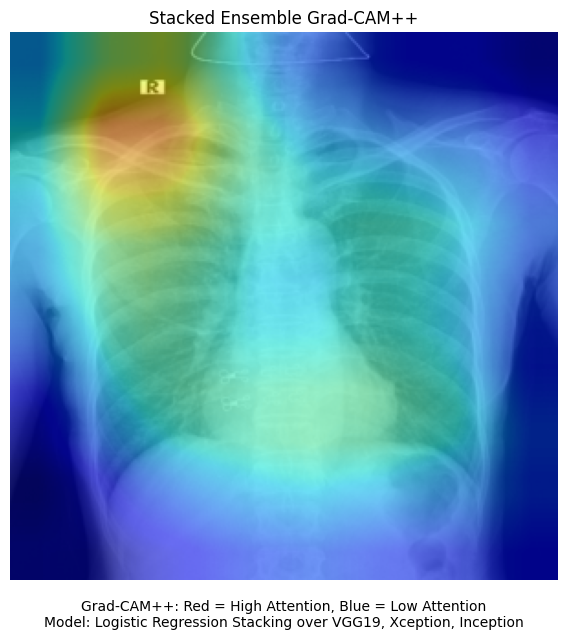

In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms

# ---------- Output Folder ----------
os.makedirs("gradcam_outputs", exist_ok=True)

# ---------- Preprocessing ----------
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# ---------- Load Sample Image ----------
sample_row = df_balanced.iloc[12]
image_id = sample_row["image_id"]
image_path = os.path.join(IMG_DIR, image_id + ".png")
image = Image.open(image_path).convert("RGB")

# Save original image
original_save_path = f"gradcam_outputs/{image_id}_original.png"
image.save(original_save_path)
print(f"🖼️ Original image saved at: {original_save_path}")

# Prepare tensor
img_tensor = transform(image).unsqueeze(0).to(DEVICE)

# ---------- Grad-CAM++ Class ----------
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)

    def __call__(self, x):
        output = self.model(x)
        class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        class_score = output[:, class_idx]
        class_score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.pow(2) / (2 * gradients.pow(2) + activations.mul(gradients.pow(3)).sum(dim=(2, 3), keepdim=True) + 1e-8)
        weights = weights.sum(dim=(2, 3), keepdim=True)

        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(299, 299), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam

# ---------- Extract CAMs ----------
vgg_target   = vgg19.features[36]
xcep_target  = xception.conv4
incep_target = model_incep.Mixed_7c

cam_vgg   = GradCAMPlusPlus(vgg19, vgg_target)(img_tensor)
cam_xcep  = GradCAMPlusPlus(xception, xcep_target)(img_tensor)
cam_incep = GradCAMPlusPlus(model_incep, incep_target)(img_tensor)

# ---------- Combine Ensemble CAM ----------
ensemble_cam = (cam_vgg + cam_xcep + cam_incep) / 3.0

# ---------- Overlay CAM on Image ----------
def overlay_cam_on_image(img_tensor, cam, alpha=0.5, title="Stacked Ensemble Grad-CAM++"):
    img_np = img_tensor.squeeze().permute(1, 2, 0).detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    heatmap = plt.cm.jet(cam)[..., :3]
    overlay = (1 - alpha) * img_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Save overlay image
    save_path = f"gradcam_outputs/{image_id}_gradcampp.png"
    plt.imsave(save_path, overlay)
    print(f"✅ Grad-CAM++ overlay saved at: {save_path}")

    # Optional display
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.title(title)
    plt.axis('off')
    plt.figtext(0.5, -0.05,
                "Grad-CAM++: Red = High Attention, Blue = Low Attention\nModel: Logistic Regression Stacking over VGG19, Xception, Inception",
                wrap=True, horizontalalignment='center', fontsize=10)
    plt.tight_layout()
    plt.show()

# ---------- Show + Save Final Output ----------
overlay_cam_on_image(img_tensor, ensemble_cam)

✅ Hooks removed from VGG19, Xception, and Inception


  0%|          | 0/1000 [00:00<?, ?it/s]

🖼️ Original image saved at: lime_outputs/d260497f6120426c51399f5f846c16b6_vascular_abnormality_original.png
✅ LIME explanation saved at: lime_outputs/d260497f6120426c51399f5f846c16b6_vascular_abnormality_lime.png


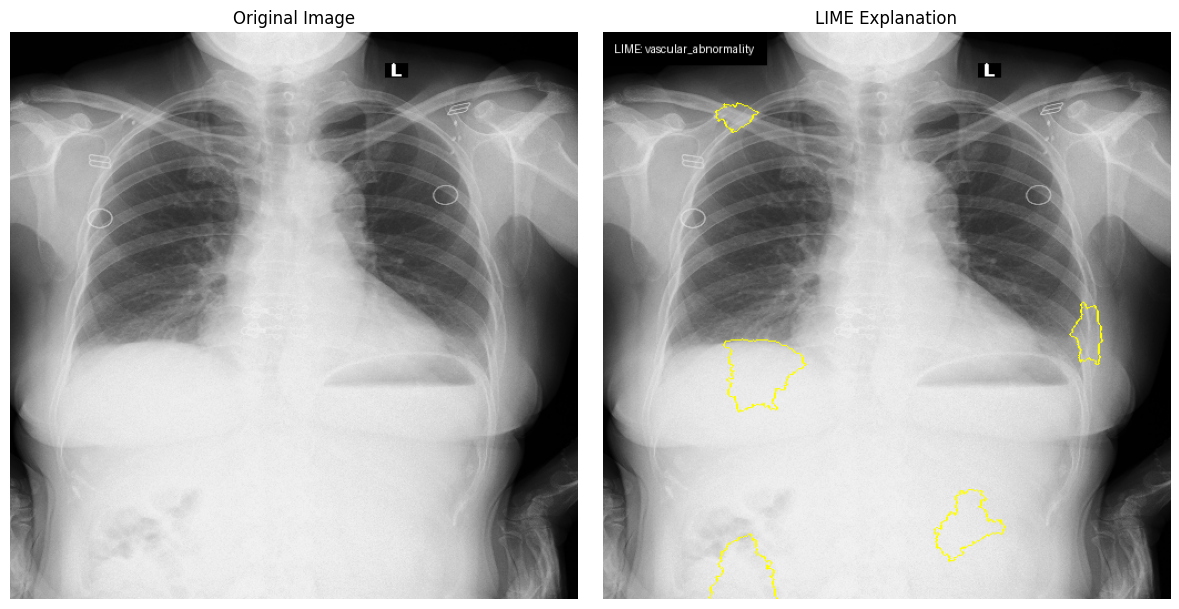

In [61]:
import os
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# -------------------- Step 1: Remove Hooks --------------------
def remove_all_hooks(model):
    for module in model.modules():
        if hasattr(module, '_forward_hooks'):
            module._forward_hooks.clear()
        if hasattr(module, '_backward_hooks'):
            module._backward_hooks.clear()
        if hasattr(module, '_forward_pre_hooks'):
            module._forward_pre_hooks.clear()

remove_all_hooks(vgg19)
remove_all_hooks(xception)
remove_all_hooks(model_incep)
print("✅ Hooks removed from VGG19, Xception, and Inception")

# -------------------- Step 2: Preprocessing --------------------
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------- Step 3: Load Image --------------------
sample_image_id = df_balanced.iloc[454]["image_id"]
image_path = os.path.join(IMG_DIR, sample_image_id + ".png")
image_pil = Image.open(image_path).convert("RGB")
img_np = np.array(image_pil)

# -------------------- Step 4: Predict Functions --------------------
def predict_base_model(model, images):
    model.eval()
    batch = torch.stack([
        preprocess(Image.fromarray(img).convert("RGB")).to(DEVICE)
        for img in images
    ])
    with torch.no_grad():
        outputs = model(batch)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

def predict_stacking(images):
    probs_vgg    = predict_base_model(vgg19, images)
    probs_xcep   = predict_base_model(xception, images)
    probs_incep  = predict_base_model(model_incep, images)
    return (probs_vgg + probs_xcep + probs_incep) / 3

# -------------------- Step 5: Run LIME --------------------
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    image=img_np,
    classifier_fn=predict_stacking,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

top_label = explanation.top_labels[0]
class_name = CLASSES[top_label].replace(" ", "_")

# -------------------- Step 6: Label Overlay Function --------------------
def add_label_on_image(np_img, label_text, font_size=24):
    image = Image.fromarray(np_img)
    draw = ImageDraw.Draw(image)

    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), label_text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    margin = 10

    # Draw rectangle and label text
    box_coords = [0, 0, text_width + 2 * margin, text_height + 2 * margin]
    draw.rectangle(box_coords, fill=(0, 0, 0))
    draw.text((margin, margin), label_text, font=font, fill=(255, 255, 255))

    return image

# -------------------- Step 7: Save Original Image (NO LABEL) --------------------
os.makedirs("lime_outputs", exist_ok=True)
original_save_path = f"lime_outputs/{sample_image_id}_{class_name}_original.png"
Image.fromarray(img_np).save(original_save_path)
print(f"🖼️ Original image saved at: {original_save_path}")

# -------------------- Step 8: Save LIME Image (WITH LABEL) --------------------
temp, mask = explanation.get_image_and_mask(
    top_label, positive_only=True, num_features=5, hide_rest=False
)
lime_result = mark_boundaries(temp / 255.0, mask)
lime_result_uint8 = (lime_result * 255).astype(np.uint8)
labeled_lime = add_label_on_image(lime_result_uint8, f"LIME: {class_name}")

lime_save_path = f"lime_outputs/{sample_image_id}_{class_name}_lime.png"
labeled_lime.save(lime_save_path)
print(f"✅ LIME explanation saved at: {lime_save_path}")

# -------------------- Step 9: Optional Display --------------------
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(labeled_lime)
plt.title("LIME Explanation")
plt.axis('off')

plt.tight_layout()
plt.show()
